In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

In [2]:
from src.graphs import ParallelEdgeGraph, NonDiagonalEdgeGraph, DiagonalEdgeGraph, StaticGraph, MultiEdgeGraph
from src.edge import Edge
from src.misc import get_cyclic_connections
from qiskit import QuantumCircuit

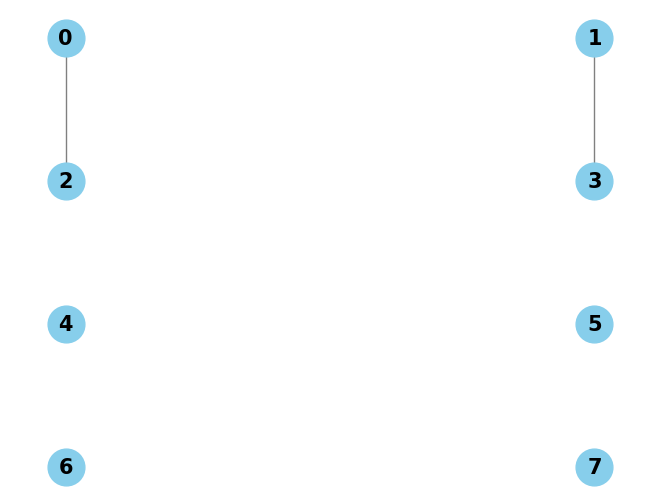

In [3]:
edges = {('000','010'),
         ('001','011')}

G = MultiEdgeGraph(edges)
G.draw()

The Quantum Circuit: 


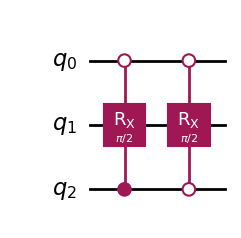

In [4]:
print('The Quantum Circuit: ')
G.get_qc().draw('mpl')

The Quantum Circuit (simplified): 


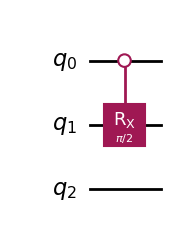

In [5]:
print('The Quantum Circuit (simplified): ')
G.get_qc(simplified=True).draw('mpl')

Target Qubits: [1, 2]
3


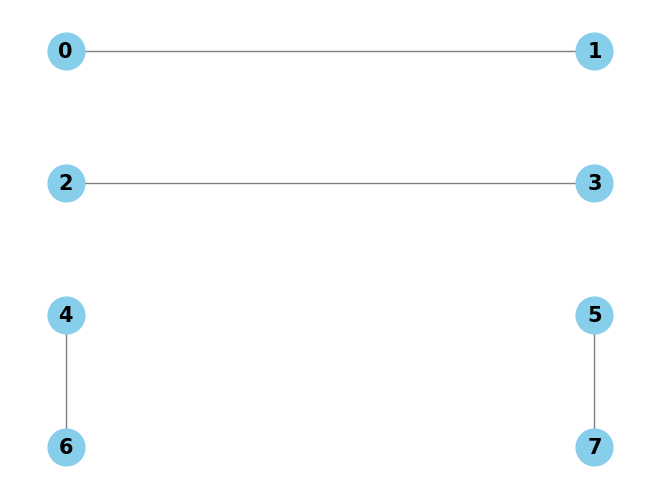

In [6]:
edges = {('000','001'),
         ('010','011'),
         ('100','110'),
         ('101','111')}

G = MultiEdgeGraph(edges)
print(f'Target Qubits: {G.targets}')
variables = set()
total_variables = variables.union(*[e.vars for e in G.exprs])
print(len(total_variables))
G.draw()

The Quantum Circuit: 


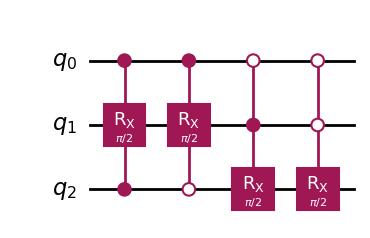

In [7]:
print('The Quantum Circuit: ')
G.get_qc().draw('mpl')

The Quantum Circuit: (simplified)


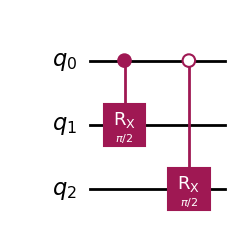

In [8]:
print('The Quantum Circuit: (simplified)')
G_simplified = MultiEdgeGraph(edges)
G_simplified.get_qc(simplified=True).draw('mpl')

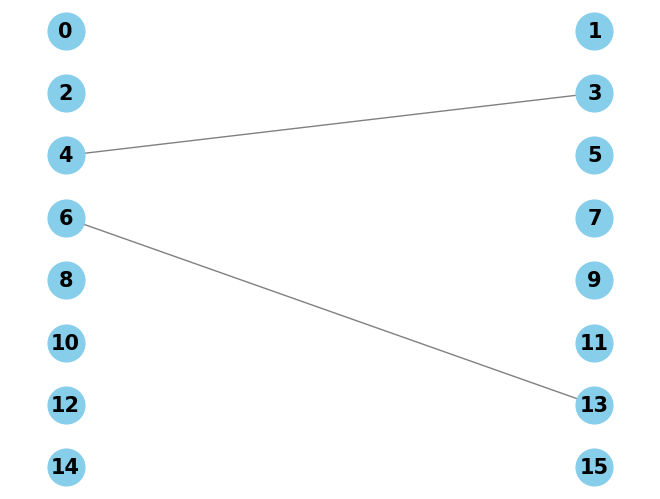

In [9]:
# edges = {('000','011'),
#          ('010','101'),
#          ('110','111')}

# edges = {('000','011'),
#          ('110','111')}

edges = {('0100','0011'),
         ('1101','0110')}

# edges = {('000','011'),
#          ('101','110')}

G = MultiEdgeGraph(edges)
G.draw()

Candidate Parallel Graph with 1 parallel groups:


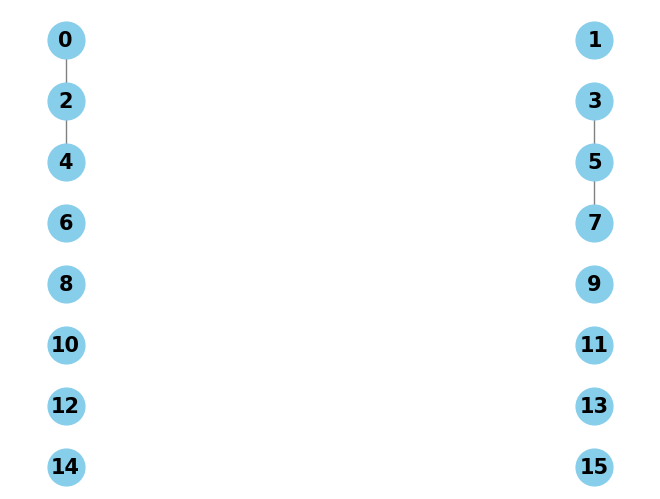

None

Quantum Circuit:


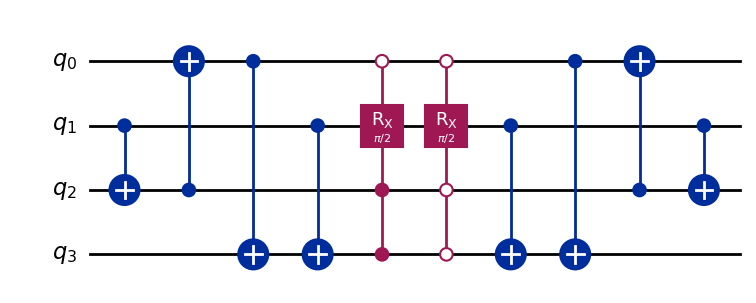

Quantum Circuit (Simplified):


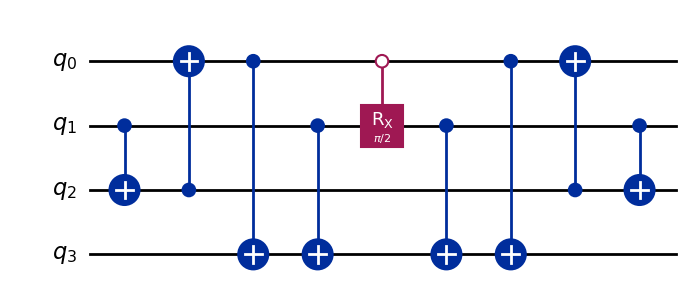

--------------------------------------------------------------------------------------
Candidate Parallel Graph with 1 parallel groups:


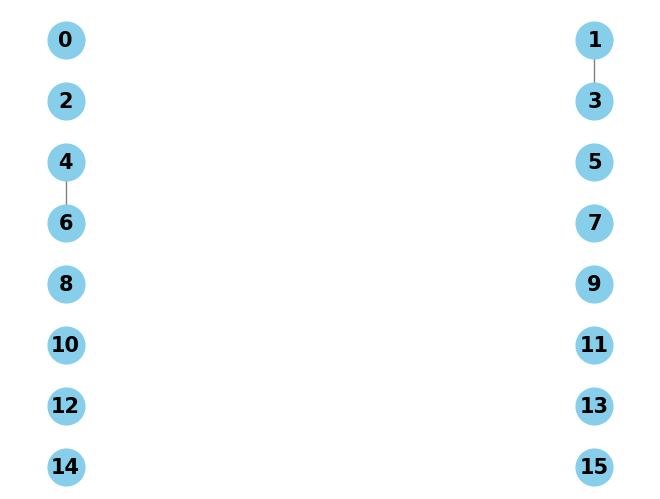

None

Quantum Circuit:


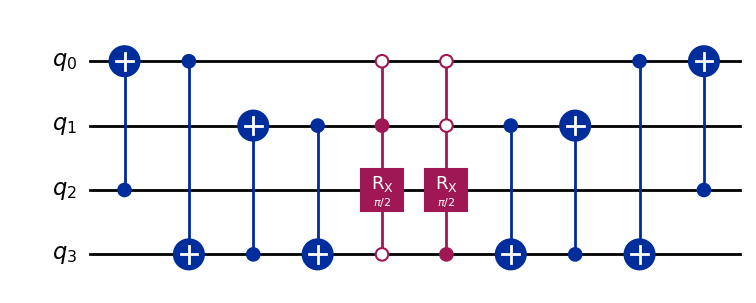

Quantum Circuit (Simplified):


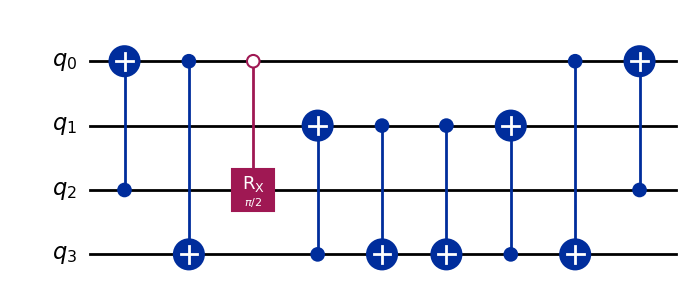

--------------------------------------------------------------------------------------
Candidate Parallel Graph with 1 parallel groups:


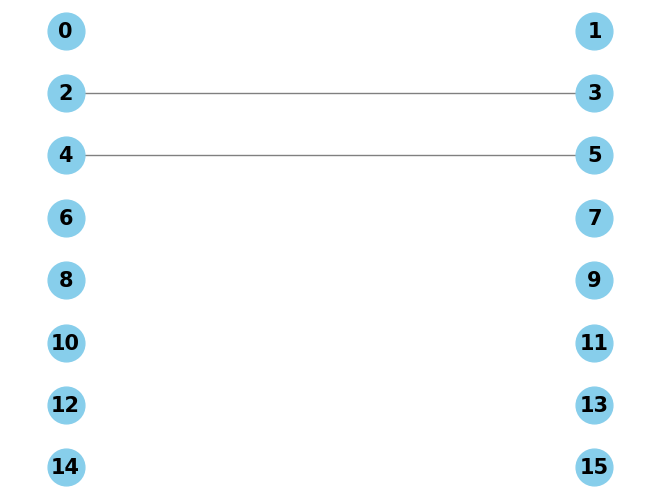

None

Quantum Circuit:


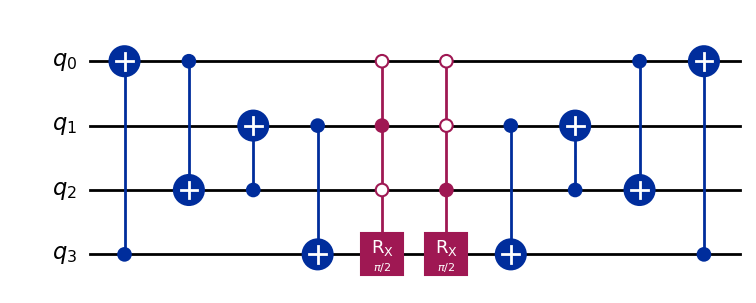

Quantum Circuit (Simplified):


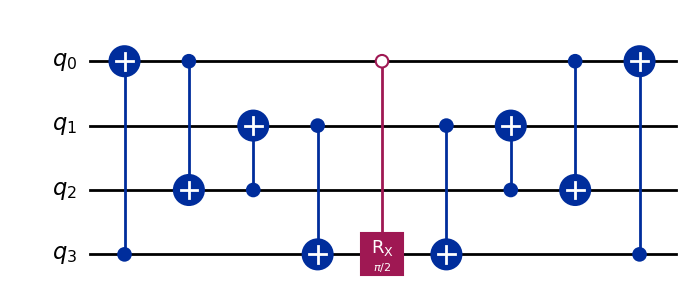

--------------------------------------------------------------------------------------
Candidate Parallel Graph with 1 parallel groups:


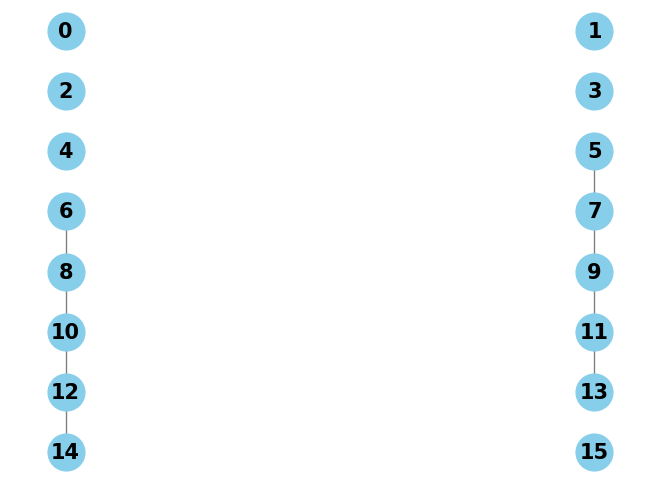

None

Quantum Circuit:


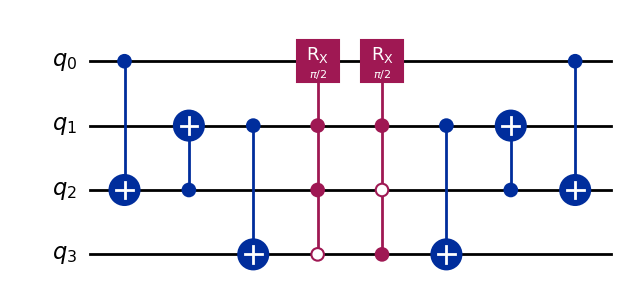

Quantum Circuit (Simplified):


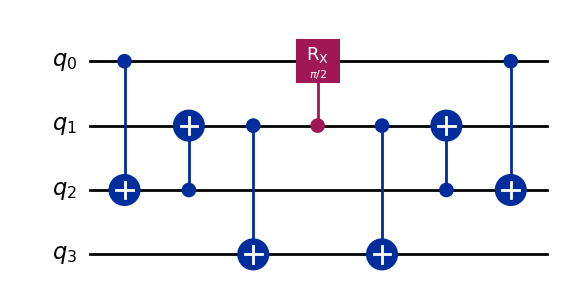

--------------------------------------------------------------------------------------
Candidate Parallel Graph with 1 parallel groups:


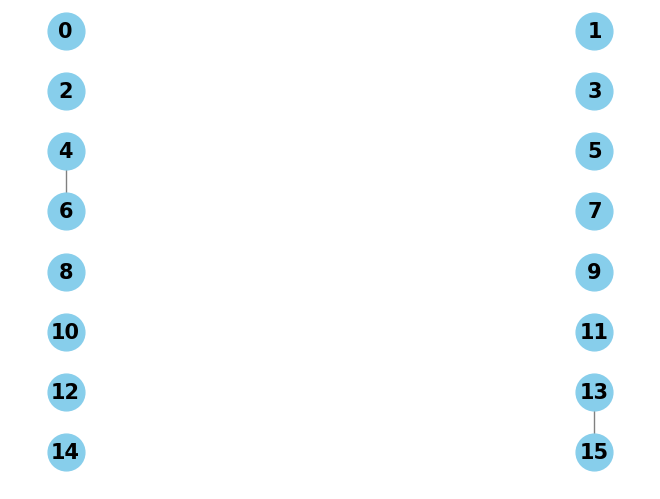

None

Quantum Circuit:


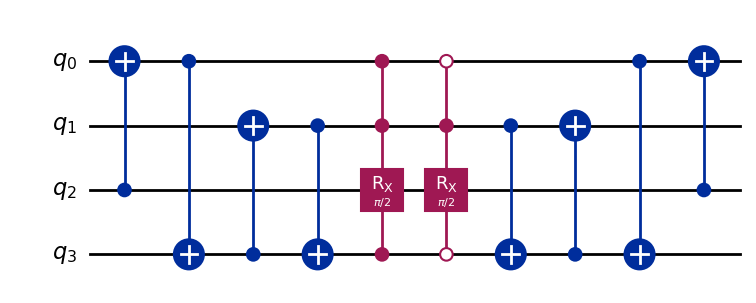

Quantum Circuit (Simplified):


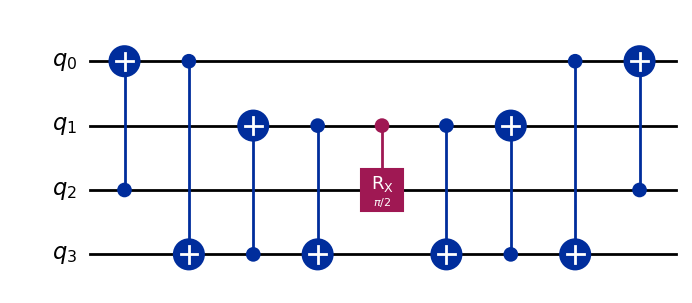

--------------------------------------------------------------------------------------
Candidate Parallel Graph with 1 parallel groups:


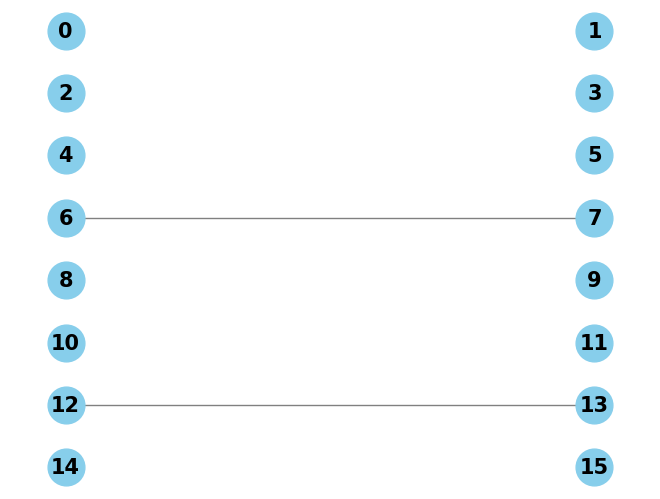

None

Quantum Circuit:


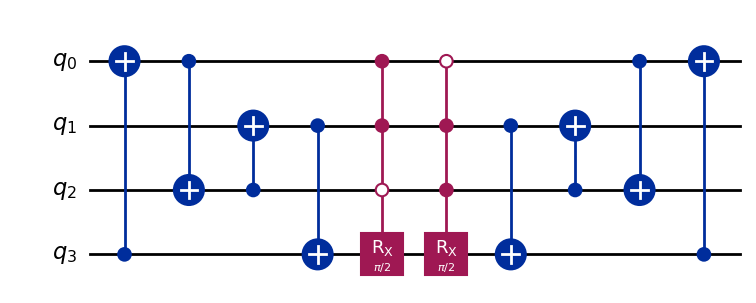

Quantum Circuit (Simplified):


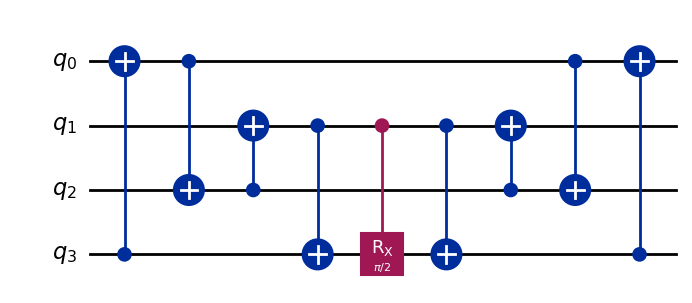

--------------------------------------------------------------------------------------


In [10]:
for e in G.candidates:
    cnots_lists = []
    for t in e.targets:
        cnots = get_cyclic_connections(G.connections, t)
        for cx in cnots:
            if cx not in cnots_lists:  
                cnots_lists.append(cx)
    
    circ = QuantumCircuit(e.n_qubits)
    for t in cnots_lists:
        circ.cx(*t)
    circ.append(e.get_qc(), range(e.n_qubits))
    for t in reversed(cnots_lists):
        circ.cx(*t)

    circ_simplified = QuantumCircuit(e.n_qubits)
    for t in cnots_lists:
        circ_simplified.cx(*t)
    circ_simplified.append(e.get_qc(simplified=True), range(e.n_qubits))
    for t in reversed(cnots_lists):
        circ_simplified.cx(*t)
    
    print(f'Candidate Parallel Graph with {len(e.edge_sets)} parallel groups:')
    display(e.draw())
    print('Quantum Circuit:')
    display(circ.decompose().draw('mpl'))
    print('Quantum Circuit (Simplified):')
    display(circ_simplified.decompose().draw('mpl'))
    print('--------------------------------------------------------------------------------------')

The Best Candidate (Graph):


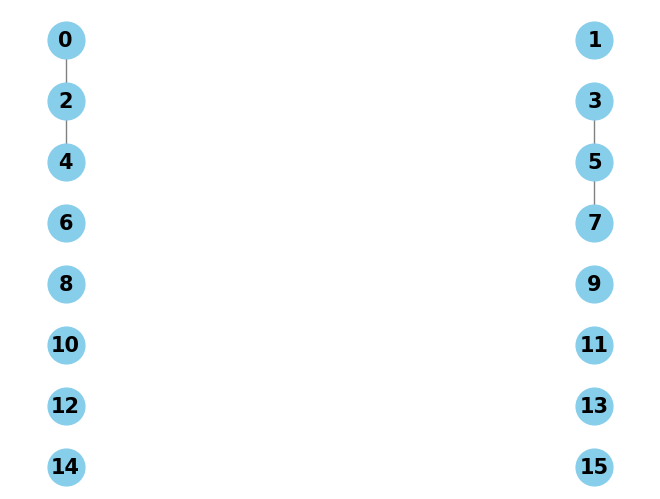

In [11]:
print('The Best Candidate (Graph):')
G.best_candidate.draw()

The Best Candidate Circuit:


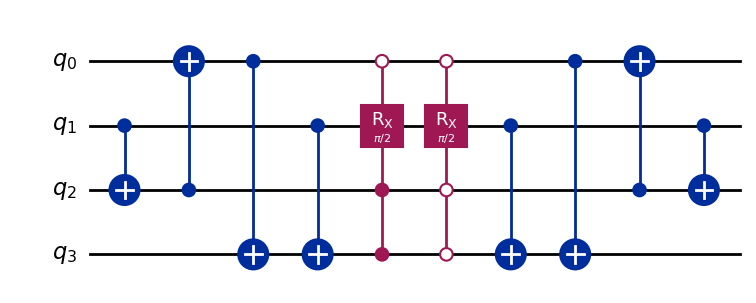

In [12]:
print('The Best Candidate Circuit:')
G.get_qc().draw('mpl')

The Best Candidate Circuit (Simplified):


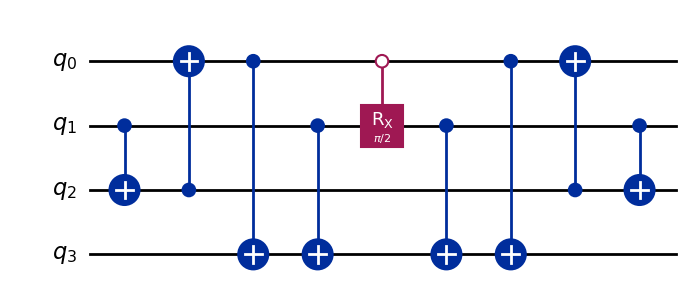

In [13]:
print('The Best Candidate Circuit (Simplified):')
G.get_qc(simplified=True).draw('mpl')